# Random Forest Classifier with Tuning and Feature Importance

A random forest is an ensemble of many decision trees. Each tree is trained on a random
subset of the data and a random subset of features, then all the trees vote on the final
prediction. Averaging many imperfect, differently-biased trees tends to produce a model
that generalizes better than any single tree, because the individual trees' mistakes are
less likely to all point the same way.

This notebook trains a random forest on the Breast Cancer Wisconsin dataset, tunes its two
most important hyperparameters, evaluates the tuned model, and looks at which features it
relies on most.

## 1. Load and split the data

The dataset describes cell nuclei measurements from breast tissue scans, with a binary
target: malignant or benign.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Classes:', dict(zip(data.target_names, np.bincount(y))))

Train shape: (455, 30)
Test shape: (114, 30)
Classes: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


## 2. Tune n_estimators and max_depth with GridSearchCV

A single decision tree can fit the training data very closely but generalize poorly. A
random forest fixes this by combining many trees, but it still has hyperparameters worth
tuning: `n_estimators` (how many trees to grow) and `max_depth` (how deep each tree is
allowed to go). More trees generally help up to a point, then give diminishing returns.
Deeper trees can capture more detail but risk overfitting.

`GridSearchCV` tries every combination of the given values, using 5-fold cross-validation
for each, and scores them by F1, a good default for a diagnostic task where both false
positives and false negatives matter.

In [2]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print('Best parameters:', grid_search.best_params_)
print(f'Best cross-validated F1: {grid_search.best_score_:.3f}')

Best parameters: {'max_depth': None, 'n_estimators': 200}
Best cross-validated F1: 0.968


## 3. Evaluate the best model

We look at two things: cross-validated F1 on the training set (already found above, a
robust estimate since it averages over 5 different train/validation splits), and
performance on the held-out test set the model has never seen, using accuracy, precision,
recall, and F1.

In [3]:
best_model = grid_search.best_estimator_

cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='f1')
print(f'Cross-validated F1 scores: {np.round(cv_scores, 3)}')
print(f'Mean cross-validated F1: {cv_scores.mean():.3f}')

y_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

print()
print(f'Test accuracy:  {test_accuracy:.3f}')
print(f'Test precision: {test_precision:.3f}')
print(f'Test recall:    {test_recall:.3f}')
print(f'Test F1:        {test_f1:.3f}')

Cross-validated F1 scores: [0.974 0.991 0.948 0.956 0.973]
Mean cross-validated F1: 0.968

Test accuracy:  0.956
Test precision: 0.959
Test recall:    0.972
Test F1:        0.966


## 4. Feature importance

Each tree in the forest picks features that best split the data at each node. Averaging
how much each feature reduces impurity across all trees gives a feature importance score.
It tells us which measurements the model actually relies on to make its predictions, which
is useful both for understanding the data and for spotting whether the model leans on
something suspicious.

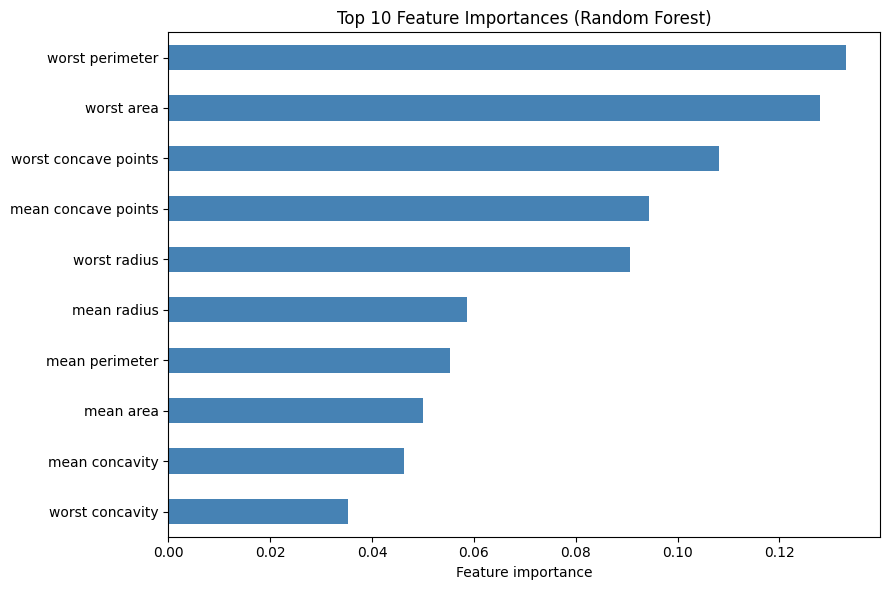

worst perimeter         0.133100
worst area              0.128052
worst concave points    0.108107
mean concave points     0.094414
worst radius            0.090639
mean radius             0.058662
mean perimeter          0.055242
mean area               0.049938
mean concavity          0.046207
worst concavity         0.035357
dtype: float64

In [4]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
top_10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 6))
top_10.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Feature importance')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

top_10